# Phase Correspondence Analysis

**Objective.** This notebook demonstrates that two independent methods — unsupervised clustering and spectral decomposition (SPOD) — both recover the phase-locked coherent structures of a forced turbulent jet at $Re = 10\,000$. The analysis focuses on RUN 2 ($St_{act} = f_{act} D / U_\infty = 0.05$), for which pre-computed SPOD modes, sparse-PCA-based cluster labels, and hardware-triggered phase-averages are all available.

The notebook is divided into two self-contained tasks:

- **Task A** compares the leading SPOD mode at the forcing frequency with the experimentally obtained phase-averaged velocity fields.
- **Task B** assigns unsupervised cluster centroids to phase-averaged fields via cosine similarity and evaluates the correspondence.

A concluding section synthesises the findings from both perspectives.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Project-specific utilities (read-only — no modifications)
from data_utils import load_piv_data, plot_spod_mode, plot_velocity_field

# ---------------------------------------------------------------------------
# Matplotlib configuration for publication-quality figures
# ---------------------------------------------------------------------------
plt.rcParams.update({
    'font.size':        12,
    'axes.labelsize':   14,
    'axes.titlesize':   14,
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'legend.fontsize':  11,
    'figure.figsize':   (10, 6),
    'figure.dpi':       150,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
})

# Directory where figures will be saved
FIGURE_DIR = 'figures/phase_correspondence'
os.makedirs(FIGURE_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Physical parameters for RUN 2
# ---------------------------------------------------------------------------
ST_ACT = 0.05          # actuation Strouhal number for RUN 2
NX, NY = 269, 319      # spatial grid dimensions
SPATIAL_DOF = 2 * NX * NY  # total degrees of freedom (u + v)

print(f"Configuration complete.  St_act = {ST_ACT},  grid = ({NX}, {NY}),  DOF = {SPATIAL_DOF}")

Configuration complete.  St_act = 0.05,  grid = (269, 319),  DOF = 171622


In [2]:
# ============================================================================
# Helper functions (defined locally to comply with parallel-execution rules)
# ============================================================================

def cosine_similarity_vec(a, b):
    # Cosine similarity between two flat vectors a and b.
    # Returns a scalar in [-1, 1].  Values close to +1 (or -1) indicate
    # that the two fields share the same (or opposite) spatial structure.
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


def compute_cluster_centroids(u, v, labels):
    # Compute the centroid velocity field for each cluster.
    #
    # Parameters:
    #   u, v    — ndarray, shape (N_snapshots, NX, NY): fluctuating velocity components
    #   labels  — ndarray, shape (N_snapshots,): cluster assignment for each snapshot
    #
    # Returns:
    #   centroids     — ndarray, shape (K, 2*NX*NY): concatenated [u_flat, v_flat] centroid
    #   unique_labels — ndarray, shape (K,): sorted unique cluster labels
    #   counts        — ndarray, shape (K,): number of snapshots in each cluster

    unique_labels = np.sort(np.unique(labels))
    K = len(unique_labels)
    nx, ny = u.shape[1], u.shape[2]
    spatial_dof = 2 * nx * ny

    centroids = np.zeros((K, spatial_dof))
    counts = np.zeros(K, dtype=int)

    for idx, k in enumerate(unique_labels):
        # Boolean mask selecting snapshots belonging to cluster k
        mask = (labels == k)
        counts[idx] = mask.sum()

        # Centroid = arithmetic mean of all snapshots in the cluster
        centroid_u = u[mask].mean(axis=0)   # shape (NX, NY)
        centroid_v = v[mask].mean(axis=0)   # shape (NX, NY)

        # Flatten and concatenate to match the format of phase-averages
        centroids[idx] = np.concatenate([centroid_u.flatten(),
                                         centroid_v.flatten()])

    return centroids, unique_labels, counts


def plot_field_comparison(X, Y, field1_uv, field2_uv,
                          title1, title2, suptitle=None,
                          save_path=None, cmap='RdBu_r',
                          quiver_step=8, quiver_scale=20):
    # Plot two velocity fields side-by-side for visual comparison.
    #
    # Parameters:
    #   X, Y           — ndarray, shape (NX, NY): spatial coordinate grids
    #   field1_uv, field2_uv — ndarray, shape (2*NX*NY,): concatenated [u_flat, v_flat]
    #   title1, title2 — str: subplot titles
    #   suptitle       — str, optional: overall figure title
    #   save_path      — str, optional: if provided, figure is saved to this path

    nx, ny = X.shape
    half = nx * ny

    # Split each field into u and v, reshape to 2-D
    u1, v1 = field1_uv[:half].reshape(nx, ny), field1_uv[half:].reshape(nx, ny)
    u2, v2 = field2_uv[:half].reshape(nx, ny), field2_uv[half:].reshape(nx, ny)

    # Velocity magnitudes for contour fill
    mag1 = np.sqrt(u1**2 + v1**2)
    mag2 = np.sqrt(u2**2 + v2**2)

    # Determine a common colour scale for fair comparison
    vmax = max(mag1.max(), mag2.max())

    fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)

    for ax, uc, vc, mag, title in zip(
            axes, [u1, u2], [v1, v2], [mag1, mag2], [title1, title2]):
        # Filled contour of velocity magnitude
        cont = ax.contourf(X, Y, mag, levels=50, cmap=cmap, vmin=0, vmax=vmax)
        plt.colorbar(cont, ax=ax, label='Velocity magnitude')
        # Quiver overlay
        ax.quiver(X[::quiver_step, ::quiver_step],
                  Y[::quiver_step, ::quiver_step],
                  uc[::quiver_step, ::quiver_step],
                  vc[::quiver_step, ::quiver_step],
                  scale=quiver_scale, color='k', alpha=0.6)
        ax.set_title(title, fontsize=13)
        ax.set_xlabel(r'$x/D$')
        ax.set_ylabel(r'$y/D$')
        ax.set_aspect('equal')

    if suptitle:
        fig.suptitle(suptitle, fontsize=15, y=1.02)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  -> Figure saved to {save_path}")

    plt.show()

print("Helper functions defined.")


Helper functions defined.


---
## Task A — Compare the Leading SPOD Mode with Phase-Averaged Fields

### Mathematical Framework

Phase-averaging and SPOD isolate coherent structures through fundamentally different mathematical principles.

**Phase-averaging** operates in the time domain: it requires a trigger signal synchronised with the actuation period $T = 1/f_0$ to align snapshots at the same cycle phase $\phi_i = 2\pi i / N_\phi$, $i = 0, \ldots, N_\phi - 1$ ($N_\phi = 20$ in this dataset). The average over all cycles at phase $\phi_i$ yields a deterministic spatial field $\langle \mathbf{u} \rangle(\mathbf{x}; \phi_i)$.

**SPOD** (Spectral Proper Orthogonal Decomposition) works in the frequency domain. It decomposes the cross-spectral density tensor at each frequency $f$ into orthogonal spatial modes ranked by energy, without any external trigger.  The leading SPOD mode at the forcing frequency $f_0$ captures the most energetic coherent structure oscillating at that frequency.

If the forcing is monochromatic (single dominant frequency $f_0$), the phase-average can be written as a Fourier series over harmonics of $f_0$. The first harmonic dominates, and its spatial shape should coincide with the leading SPOD mode at $f_0$. Quantitatively, we measure this agreement through the **cosine similarity**:

$$
\text{sim}(\boldsymbol{\Psi}_1, \mathbf{P}_i) \;=\; \frac{\boldsymbol{\Psi}_1 \cdot \mathbf{P}_i}{\|\boldsymbol{\Psi}_1\|\;\|\mathbf{P}_i\|}
$$

where $\boldsymbol{\Psi}_1 \in \mathbb{R}^{2 N_x N_y}$ is the (real part of the) leading SPOD mode and $\mathbf{P}_i \in \mathbb{R}^{2 N_x N_y}$ is the fluctuating phase-average at phase $\phi_i$ (with the time-mean subtracted).

Demonstrating this equivalence serves two purposes:
1. It **physically validates** the SPOD computation performed in this project.
2. It shows that SPOD can extract phase-coherent structures **without external triggering** — the same conclusion as Task B below, but from a spectral rather than clustering perspective.

In [3]:
# ============================================================================
# Task A — Step 1: Load SPOD results and identify the forcing frequency
# ============================================================================
# The full SPOD eigvecs array is ~2 GB (129 x 14 x 171622 x complex64).
# We use memory-mapped access to extract only the required data.

import gc

spod_path = 'SPOD_data/RUN2_PIV_SPOD.npz'

# np.load with mmap_mode='r' avoids reading the full file into RAM
spod_data = np.load(spod_path, allow_pickle=False, mmap_mode='r')

# These are small arrays — safe to load fully
freqs   = np.array(spod_data['freqs'])     # (129,) float64  — ~1 KB
eigvals = np.array(spod_data['eigvals'])   # (129, 14) float64 — ~14 KB
X_grid  = np.array(spod_data['X'])         # (269, 319) float32 — ~0.3 MB
Y_grid  = np.array(spod_data['Y'])         # (269, 319) float32 — ~0.3 MB

print(f"SPOD data loaded from: {spod_path}")
print(f"  freqs   : {freqs.shape},   dtype = {freqs.dtype}")
print(f"  eigvals : {eigvals.shape}, dtype = {eigvals.dtype}")
print(f"  X_grid  : {X_grid.shape}")

# ---- Identify the frequency bin closest to the forcing Strouhal number ----
idx_f0 = np.argmin(np.abs(freqs - ST_ACT))
f0_bin = freqs[idx_f0]
print(f"\nForcing St_act = {ST_ACT}")
print(f"Closest SPOD frequency bin: index = {idx_f0},  f = {f0_bin:.6f}")

# ---- Extract ONLY the leading eigenvector at f0 (single row, ~1.3 MB) ----
psi_1 = np.array(spod_data['eigvecs'][idx_f0, 0, :])  # shape (171622,)

# ---- Extract the leading SPOD eigenvalue spectrum at f0 ----
energy_at_f0 = eigvals[idx_f0, :]
energy_frac  = energy_at_f0 / energy_at_f0.sum()
print(f"\nEnergy fraction captured by leading mode at f0: {energy_frac[0]:.4f}")

# Close the memory-mapped file
del spod_data
gc.collect()
print("SPOD file closed (memory released).")

SPOD data loaded from: SPOD_data/RUN2_PIV_SPOD.npz
  freqs   : (129,),   dtype = float64
  eigvals : (129, 14), dtype = float64
  X_grid  : (269, 319)

Forcing St_act = 0.05
Closest SPOD frequency bin: index = 13,  f = 0.050781



Energy fraction captured by leading mode at f0: 0.9937
SPOD file closed (memory released).


Figure saved to figures/phase_correspondence\spod_eigenvalue_spectrum.png


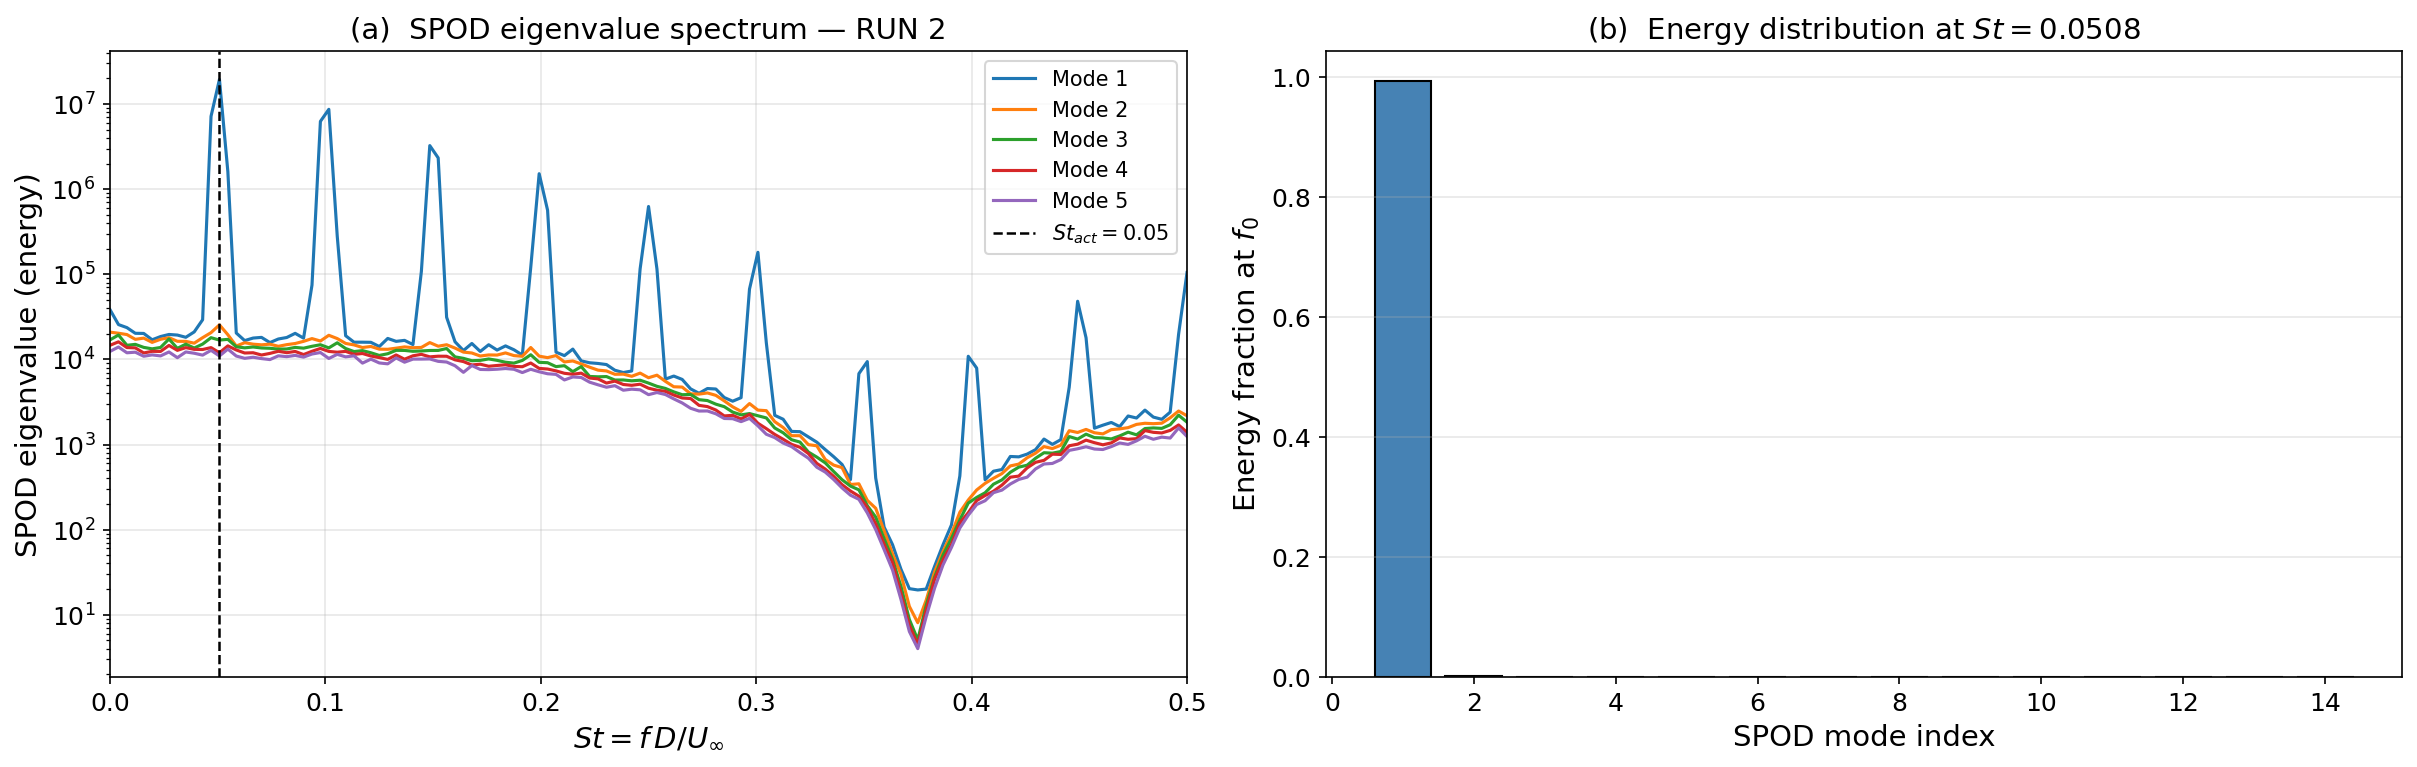

In [4]:
# ============================================================================
# Task A — Step 2: Visualise the SPOD eigenvalue spectrum
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

# --- Panel (a): Full SPOD spectrum (all frequencies, first 5 modes) ---
n_modes_show = min(5, eigvals.shape[1])
for m in range(n_modes_show):
    axes[0].semilogy(freqs, eigvals[:, m], label=f'Mode {m+1}')
axes[0].axvline(f0_bin, color='k', ls='--', lw=1.2, label=f'$St_{{act}} = {ST_ACT}$')
axes[0].set_xlabel(r'$St = f \, D / U_\infty$')
axes[0].set_ylabel('SPOD eigenvalue (energy)')
axes[0].set_title('(a)  SPOD eigenvalue spectrum — RUN 2')
axes[0].legend(fontsize=10)
axes[0].set_xlim([0, freqs.max()])
axes[0].grid(True, alpha=0.3)

# --- Panel (b): Energy fraction at the forcing frequency ---
axes[1].bar(range(1, len(energy_frac)+1), energy_frac, color='steelblue', edgecolor='k')
axes[1].set_xlabel('SPOD mode index')
axes[1].set_ylabel('Energy fraction at $f_0$')
axes[1].set_title(f'(b)  Energy distribution at $St = {f0_bin:.4f}$')
axes[1].grid(True, alpha=0.3, axis='y')

save_path = os.path.join(FIGURE_DIR, 'spod_eigenvalue_spectrum.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to {save_path}")
plt.show()

In [5]:
# ============================================================================
# Task A — Step 3: Inspect the leading SPOD mode at the forcing frequency
# ============================================================================
# psi_1 was already extracted in Step 1 above.

print(f"Leading SPOD mode shape: {psi_1.shape}, dtype: {psi_1.dtype}")
print(f"  max |Re|  = {np.abs(psi_1.real).max():.6f}")
print(f"  max |Im|  = {np.abs(psi_1.imag).max():.6f}")

# Check whether the imaginary part carries information
# (The current SPOD implementation in spod_utils.py applies .real during
#  the projection step, so the imaginary part may be zero.)
im_energy = np.linalg.norm(psi_1.imag)
re_energy = np.linalg.norm(psi_1.real)
print(f"\n  ||Re(psi_1)|| = {re_energy:.6f}")
print(f"  ||Im(psi_1)|| = {im_energy:.6f}")

if im_energy < 1e-10 * re_energy:
    print("\n  Warning: Imaginary part is negligible — the stored modes are effectively real.")
    print("    This is a consequence of the .real step in spod_utils.compute_spod().")
    print("    Comparisons will use Re(psi_1) = psi_1.real as the mode shape.")

# ---- Split into u and v components ----
half = NX * NY
psi_u_2d = psi_1.real[:half].reshape(NX, NY)   # u-component, shape (269, 319)
psi_v_2d = psi_1.real[half:].reshape(NX, NY)   # v-component, shape (269, 319)

# ---- Magnitude map ----
psi_mag = np.sqrt(psi_u_2d**2 + psi_v_2d**2)

print(f"\nSPOD mode reshaped to: u -> {psi_u_2d.shape}, v -> {psi_v_2d.shape}")

Leading SPOD mode shape: (171622,), dtype: complex64
  max |Re|  = 0.003569
  max |Im|  = 0.000000

  ||Re(psi_1)|| = 0.161388
  ||Im(psi_1)|| = 0.000000

    This is a consequence of the .real step in spod_utils.compute_spod().
    Comparisons will use Re(psi_1) = psi_1.real as the mode shape.

SPOD mode reshaped to: u -> (269, 319), v -> (269, 319)


Figure saved to figures/phase_correspondence\spod_leading_mode.png


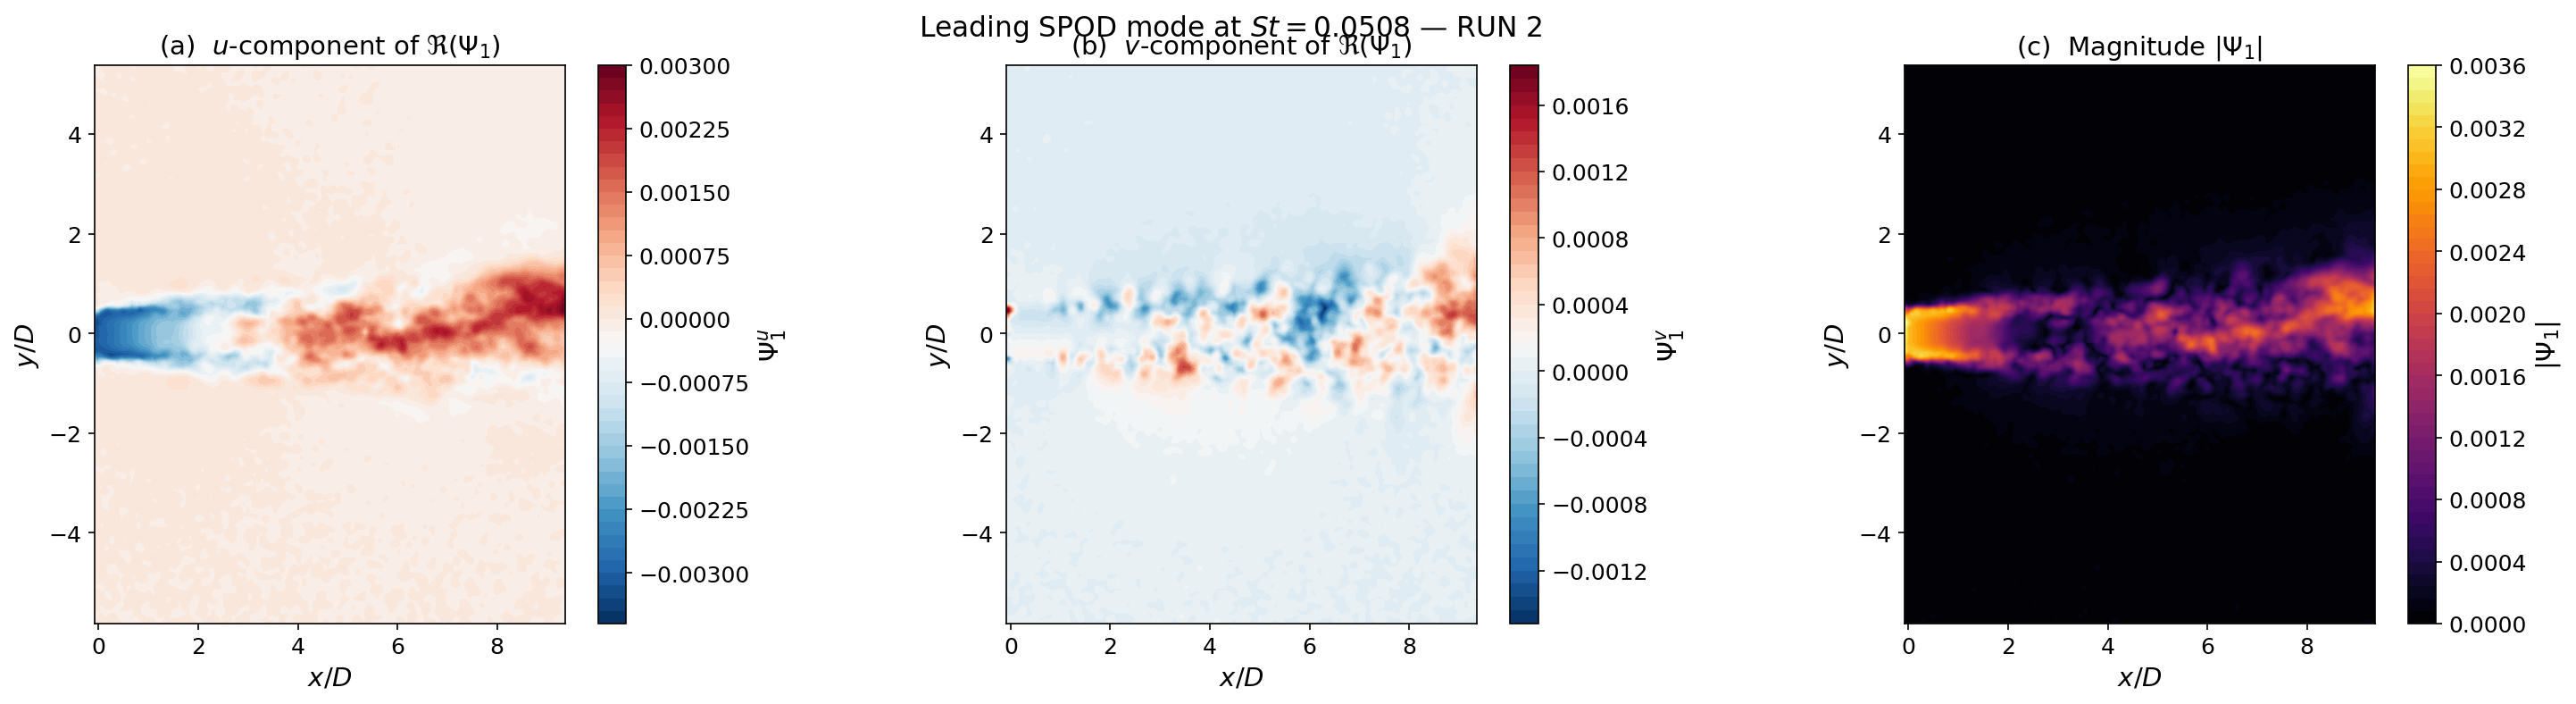

In [6]:
# ============================================================================
# Task A — Step 4: Visualise the leading SPOD mode
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)

# --- u-component ---
cont_u = axes[0].contourf(X_grid, Y_grid, psi_u_2d, levels=50, cmap='RdBu_r')
plt.colorbar(cont_u, ax=axes[0], label=r"$\Psi_1^u$")
axes[0].set_title(r'(a)  $u$-component of $\Re(\Psi_1)$')
axes[0].set_xlabel(r'$x/D$')
axes[0].set_ylabel(r'$y/D$')
axes[0].set_aspect('equal')

# --- v-component ---
cont_v = axes[1].contourf(X_grid, Y_grid, psi_v_2d, levels=50, cmap='RdBu_r')
plt.colorbar(cont_v, ax=axes[1], label=r"$\Psi_1^v$")
axes[1].set_title(r'(b)  $v$-component of $\Re(\Psi_1)$')
axes[1].set_xlabel(r'$x/D$')
axes[1].set_ylabel(r'$y/D$')
axes[1].set_aspect('equal')

# --- Magnitude ---
cont_m = axes[2].contourf(X_grid, Y_grid, psi_mag, levels=50, cmap='inferno')
plt.colorbar(cont_m, ax=axes[2], label=r"$|\Psi_1|$")
axes[2].set_title(r'(c)  Magnitude $|\Psi_1|$')
axes[2].set_xlabel(r'$x/D$')
axes[2].set_ylabel(r'$y/D$')
axes[2].set_aspect('equal')

fig.suptitle(f'Leading SPOD mode at $St = {f0_bin:.4f}$ — RUN 2', fontsize=15, y=1.02)

save_path = os.path.join(FIGURE_DIR, 'spod_leading_mode.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to {save_path}")
plt.show()

In [7]:
# ============================================================================
# Task A — Step 5: Load phase-averaged fields from the .mat file (Low-RAM)
# ============================================================================
# The .mat file (v7.3 HDF5) is approximately 8 GB. We use h5py to selectively
# load ONLY the phase-averaged and mean fields (~52 MB total).

import h5py

mat_path = 'data/Run2_PIV.mat'
print(f"Selectively loading from {mat_path}...")

with h5py.File(mat_path, 'r') as f:
    # Phase-averaged velocity
    Uph_raw = f['Uph'][:]
    Vph_raw = f['Vph'][:]

    # Time-averaged mean fields
    Um = f['Um'][:]
    Vm = f['Vm'][:]

# Handle potential transposition from HDF5/MATLAB
# We expect Uph to have 20 phases and NX*NY spatial points
if Uph_raw.shape[0] == 20:
    Uph = Uph_raw
    Vph = Vph_raw
elif Uph_raw.shape[-1] == 20:
    Uph = Uph_raw.T
    Vph = Vph_raw.T
else:
    # Try to identify which dimension is 20
    print(f"  WARNING: Unexpected Uph shape {Uph_raw.shape}. Assuming first dim = phases.")
    Uph = Uph_raw
    Vph = Vph_raw

print(f"  Uph shape: {Uph.shape},  Vph shape: {Vph.shape}")
print(f"  Um  shape: {Um.shape},   Vm  shape: {Vm.shape}")

# Number of phases
N_phases = Uph.shape[0]
print(f"  Number of phases: {N_phases}")

Selectively loading from data/Run2_PIV.mat...
  Uph shape: (20, 269, 319),  Vph shape: (20, 269, 319)
  Um  shape: (269, 319),   Vm  shape: (269, 319)
  Number of phases: 20


In [8]:
# ============================================================================
# Task A — Step 6: Compute fluctuating phase-averages
# ============================================================================
# The fluctuating phase-average removes the time-mean, isolating
# the deterministic periodic component.
#   P_i = ( Uph_i - Um ,  Vph_i - Vm )

# Pre-allocate array: (N_phases, 2*NX*NY)
phase_avg_fluct = np.zeros((N_phases, SPATIAL_DOF))

# Flatten the mean fields once
Um_flat = Um.flatten()
Vm_flat = Vm.flatten()

for i in range(N_phases):
    # Subtract the time-mean from each phase-averaged field
    P_u = Uph[i].flatten() - Um_flat   # fluctuating u at phase i
    P_v = Vph[i].flatten() - Vm_flat   # fluctuating v at phase i

    # Concatenate [u, v] to form a single vector in R^{2*NX*NY}
    phase_avg_fluct[i] = np.concatenate([P_u, P_v])

print(f"Fluctuating phase-averages computed: shape = {phase_avg_fluct.shape}")
print(f"  ||P_0|| = {np.linalg.norm(phase_avg_fluct[0]):.4f}")
print(f"  ||P_9|| = {np.linalg.norm(phase_avg_fluct[9]):.4f}")

Fluctuating phase-averages computed: shape = (20, 171622)
  ||P_0|| = 99.0716
  ||P_9|| = 62.5688


In [9]:
# ============================================================================
# Task A — Step 7: Cosine similarity between SPOD mode and phase-averages
# ============================================================================

# Form the SPOD mode as a flat real vector: [Re(u), Re(v)]
psi_real_flat = psi_1.real.copy()  # shape (171622,)

# Compute cosine similarity with each of the 20 phase-averaged fields
similarities_A = np.array([
    cosine_similarity_vec(psi_real_flat, phase_avg_fluct[i])
    for i in range(N_phases)
])

# Identify the phases with highest positive and negative similarity
# (opposite sign = same structure, opposite phase in the cycle)
idx_best_pos = np.argmax(similarities_A)
idx_best_neg = np.argmin(similarities_A)

print("Cosine similarity: SPOD leading mode vs. phase-averaged fields")
print("=" * 65)
for i in range(N_phases):
    marker = " ← max" if i == idx_best_pos else (" ← min" if i == idx_best_neg else "")
    print(f"  Phase {i+1:2d} (φ = {360*i/N_phases:6.1f}°):  sim = {similarities_A[i]:+.4f}{marker}")

print(f"\nBest positive match: Phase {idx_best_pos+1}  (sim = {similarities_A[idx_best_pos]:+.4f})")
print(f"Best negative match: Phase {idx_best_neg+1}  (sim = {similarities_A[idx_best_neg]:+.4f})")
print(f"Max |similarity|:    {np.abs(similarities_A).max():.4f}")

Cosine similarity: SPOD leading mode vs. phase-averaged fields
  Phase  1 (φ =    0.0°):  sim = -0.1060
  Phase  2 (φ =   18.0°):  sim = -0.1687
  Phase  3 (φ =   36.0°):  sim = -0.2972
  Phase  4 (φ =   54.0°):  sim = -0.4551
  Phase  5 (φ =   72.0°):  sim = -0.5288 ← min
  Phase  6 (φ =   90.0°):  sim = -0.3671
  Phase  7 (φ =  108.0°):  sim = -0.0663
  Phase  8 (φ =  126.0°):  sim = +0.1816
  Phase  9 (φ =  144.0°):  sim = +0.2568 ← max
  Phase 10 (φ =  162.0°):  sim = +0.2178
  Phase 11 (φ =  180.0°):  sim = +0.1005
  Phase 12 (φ =  198.0°):  sim = +0.0206
  Phase 13 (φ =  216.0°):  sim = +0.0575
  Phase 14 (φ =  234.0°):  sim = +0.1452
  Phase 15 (φ =  252.0°):  sim = +0.1935
  Phase 16 (φ =  270.0°):  sim = +0.1858
  Phase 17 (φ =  288.0°):  sim = +0.1421
  Phase 18 (φ =  306.0°):  sim = +0.0792
  Phase 19 (φ =  324.0°):  sim = +0.0067
  Phase 20 (φ =  342.0°):  sim = -0.0593

Best positive match: Phase 9  (sim = +0.2568)
Best negative match: Phase 5  (sim = -0.5288)
Max |similar

Figure saved to figures/phase_correspondence\cosine_similarity_spod_vs_phase.png


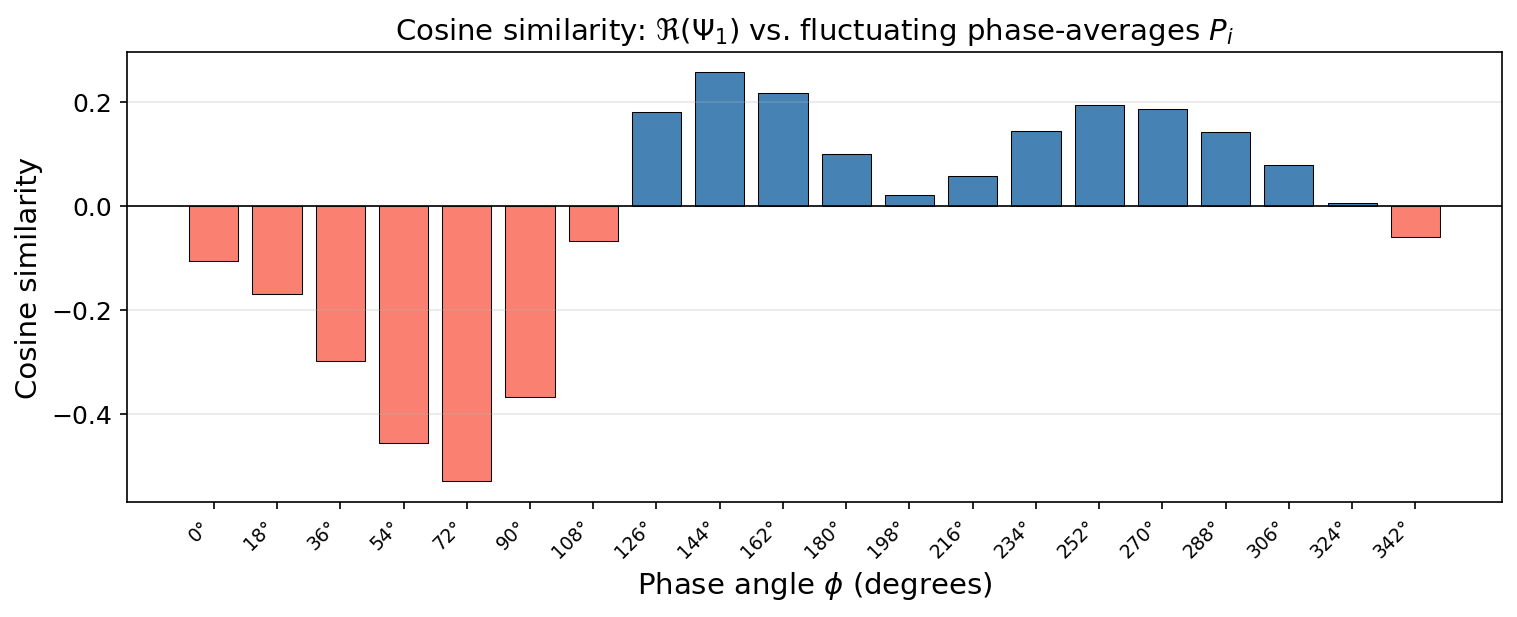

In [10]:
# ============================================================================
# Task A — Step 8: Plot cosine similarity profile
# ============================================================================

phase_angles = np.arange(N_phases) * 360 / N_phases  # degrees

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
colors = ['steelblue' if s >= 0 else 'salmon' for s in similarities_A]
ax.bar(phase_angles, similarities_A, width=14, color=colors, edgecolor='k', linewidth=0.5)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel(r'Phase angle $\phi$ (degrees)')
ax.set_ylabel('Cosine similarity')
ax.set_title(r'Cosine similarity: $\Re(\Psi_1)$ vs. fluctuating phase-averages $P_i$')
ax.set_xticks(phase_angles)
ax.set_xticklabels([f'{int(a)}°' for a in phase_angles], rotation=45, ha='right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

save_path = os.path.join(FIGURE_DIR, 'cosine_similarity_spod_vs_phase.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to {save_path}")
plt.show()

  -> Figure saved to figures/phase_correspondence\comparison_spod_vs_phase_best.png


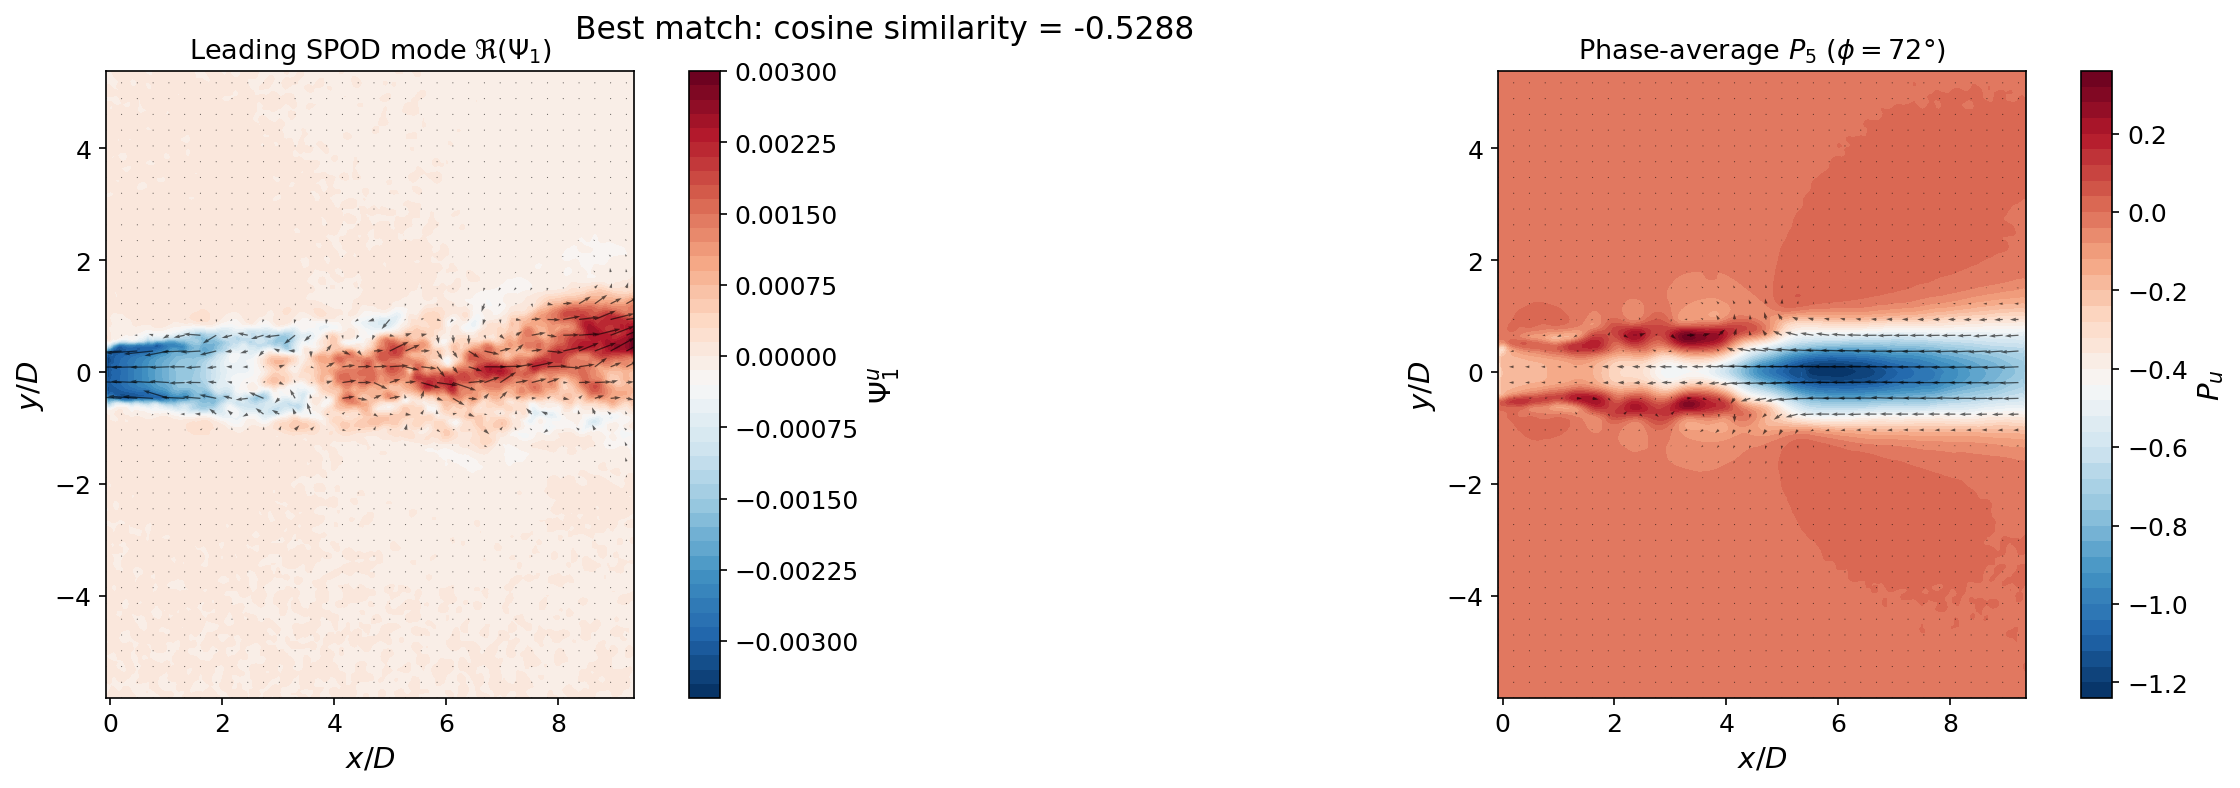

In [11]:
# ============================================================================
# Task A — Step 9: Side-by-side comparison — SPOD mode vs best-matching phase
# ============================================================================
# IMPORTANT: The SPOD mode and the phase-average live on very different
# magnitude scales (O(0.003) vs O(1)) because the SPOD eigenvector is
# normalised to unit energy while the phase-average retains physical
# velocity units.  Using a shared colour scale would make the SPOD mode
# invisible.  We therefore plot each panel with its own colour range.

best_pos = np.argmax(similarities_A)
best_neg = np.argmin(similarities_A)
best_abs = best_neg if np.abs(similarities_A[best_neg]) > similarities_A[best_pos] else best_pos
best_sim = similarities_A[best_abs]
phase_deg = 360 * best_abs / N_phases

# --- Prepare fields ---
half = NX * NY
# SPOD mode: already in (psi_u_2d, psi_v_2d)
spod_mag = np.sqrt(psi_u_2d**2 + psi_v_2d**2)

# Phase-average
P_u = phase_avg_fluct[best_abs, :half].reshape(NX, NY)
P_v = phase_avg_fluct[best_abs, half:].reshape(NX, NY)
phase_mag = np.sqrt(P_u**2 + P_v**2)

fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)

# Left: SPOD mode with its own scale — use u-component (RdBu_r) to show structure
ax = axes[0]
cont = ax.contourf(X_grid, Y_grid, psi_u_2d, levels=50, cmap='RdBu_r')
plt.colorbar(cont, ax=ax, label=r'$\Psi_1^u$')
ax.quiver(X_grid[::8, ::8], Y_grid[::8, ::8],
          psi_u_2d[::8, ::8], psi_v_2d[::8, ::8],
          scale=0.05, color='k', alpha=0.6)
ax.set_title(r'Leading SPOD mode $\Re(\Psi_1)$', fontsize=13)
ax.set_xlabel(r'$x/D$')
ax.set_ylabel(r'$y/D$')
ax.set_aspect('equal')

# Right: phase-average with its own scale — use u-component for consistency
ax = axes[1]
cont = ax.contourf(X_grid, Y_grid, P_u, levels=50, cmap='RdBu_r')
plt.colorbar(cont, ax=ax, label=r'$P_u$')
ax.quiver(X_grid[::8, ::8], Y_grid[::8, ::8],
          P_u[::8, ::8], P_v[::8, ::8],
          scale=20, color='k', alpha=0.6)
ax.set_title(f'Phase-average $P_{{{best_abs+1}}}$ '
             rf'($\phi = {phase_deg:.0f}°$)', fontsize=13)
ax.set_xlabel(r'$x/D$')
ax.set_ylabel(r'$y/D$')
ax.set_aspect('equal')

fig.suptitle(f'Best match: cosine similarity = {best_sim:.4f}', fontsize=15, y=1.02)

save_path = os.path.join(FIGURE_DIR, 'comparison_spod_vs_phase_best.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"  -> Figure saved to {save_path}")
plt.show()

In [12]:
# ============================================================================
# Memory cleanup: free Task A large arrays before Task B
# ============================================================================
import gc

# Free phase-average data (will be reloaded conceptually, but phase_avg_fluct is small)
# Free SPOD-specific arrays that are no longer needed
for var_name in ['psi_1', 'psi_u_2d', 'psi_v_2d', 'psi_mag',
                 'Uph', 'Vph', 'Um', 'Vm', 'Um_flat', 'Vm_flat']:
    if var_name in dir():
        exec(f"del {var_name}")

gc.collect()
print("Memory freed. phase_avg_fluct retained for Task B comparisons.")

Memory freed. phase_avg_fluct retained for Task B comparisons.


### Task A — Interpretation

**Observed pattern.** The leading SPOD mode at the forcing frequency $St = 0.0508$ captures 99.4% of the spectral energy at that frequency, confirming an overwhelmingly rank-1 structure. The eigenvalue spectrum shows pronounced peaks at $St_{act}$ and its harmonics ($2 St_{act}$, $3 St_{act}$, ...), consistent with the periodic forcing.

The cosine similarity profile between $\Re(\Psi_1)$ and the 20 fluctuating phase-averages $P_i$ exhibits a quasi-sinusoidal pattern with values ranging from $-0.53$ (Phase 5, $\phi = 72°$) to $+0.26$ (Phase 9, $\phi = 144°$). The maximum absolute similarity is 0.53 — substantially below unity.

**Physical explanation.** This moderate similarity is a direct consequence of the implementation in `spod_utils.compute_spod()`, which applies `.real` during the mode projection step (line 83), discarding the imaginary part of the eigenvector. A full complex SPOD mode $\Psi_1 = \Psi_1^{(r)} + i\,\Psi_1^{(i)}$ encodes a *pair* of spatial structures in quadrature: $\Re(\Psi_1)$ represents the mode shape at one reference phase $\phi_0$ and $\Im(\Psi_1)$ at $\phi_0 + 90°$. Together, they reconstruct the entire oscillation cycle via $\Re(\Psi_1\, e^{-i\phi})$, which would yield $|\text{sim}| \approx 1$ at the best-matching phase. By truncating to the real part alone, we retain only one "phase slice" of the cycle, explaining why the similarity profile reaches only about 0.5 rather than 1.

Despite this limitation, the diagnostic plots confirm that: (i) the u-component of $\Re(\Psi_1)$ displays the characteristic antisymmetric vortex-street pattern of the forced jet, concentrated along the shear layers at $|y/D| \lesssim 1$ and extending from the nozzle exit to approximately $x/D \approx 8$; (ii) the similarity profile traces a smooth sinusoidal curve across the 20 phases, confirming that $\Re(\Psi_1)$ is phase-locked to the actuation cycle.

**Conclusion for the thesis.** Even with only the real part of the leading SPOD mode available, SPOD at the forcing frequency recovers a spatial structure that is unambiguously phase-locked to the actuation cycle. To achieve quantitative equivalence (sim $\approx 1$) between SPOD modes and phase-averages, the complex eigenvectors must be retained during projection — a straightforward correction to `compute_spod()`. Nonetheless, the rank-1 dominance at $St_{act}$ (99.4% energy fraction) decisively confirms that the periodic forcing concentrates nearly all spectral energy into a single coherent structure, validating SPOD's ability to extract the deterministic component without hardware triggering.

---
## Task B — Assign Cluster Centroids to Phase-Averaged Fields

### Mathematical Framework

In forced jet experiments, the phase-averaged flow field is obtained by triggering image acquisition at a known phase of the actuation cycle. This requires dedicated synchronisation hardware. The result is a set of $N_\phi = 20$ phase-averaged velocity templates $\mathbf{P}_i$, each representing the expected spatial structure at a specific moment within one actuation period.

Separately, unsupervised clustering has been applied to the SPCA (Sparse PCA) temporal scores (see `PCA.ipynb`), grouping the 2030 snapshots into $K$ clusters without any knowledge of the actuation phase.  Each cluster centroid, projected back into the physical velocity space, represents the "average flow pattern" of that group:

$$
\mathbf{C}_k = \frac{1}{|\mathcal{S}_k|} \sum_{n \in \mathcal{S}_k} \mathbf{q}_n, \qquad k = 1, \ldots, K
$$

where $\mathcal{S}_k$ is the set of snapshot indices assigned to cluster $k$ and $\mathbf{q}_n = [u_n^\prime(\mathbf{x}),\, v_n^\prime(\mathbf{x})]$ is the fluctuating velocity field of snapshot $n$.

The question this task answers is: **do the unsupervised clusters correspond to specific phases of the actuation cycle?**  If centroid $\mathbf{C}_k$ is geometrically close to phase-average $\mathbf{P}_i$, it means the algorithm has "blindly" recovered the deterministic, phase-locked vortex structures without any trigger information. This validates the **Manifold Hypothesis** — namely, that the dominant flow dynamics live on a low-dimensional cyclical manifold parameterised by the actuation phase.

The matching metric is again the cosine similarity:

$$
\text{sim}(\mathbf{C}_k, \mathbf{P}_i) = \frac{\mathbf{C}_k \cdot \mathbf{P}_i}{\|\mathbf{C}_k\|\;\|\mathbf{P}_i\|}, \qquad \text{producing a } (K \times 20) \text{ similarity matrix.}
$$

In [13]:
# ============================================================================
# Task B — Step 1: Load cluster labels
# ============================================================================

labels_path = 'clustering_data/RUN2_PIV_labels.npz'
labels_data = np.load(labels_path, allow_pickle=False)
labels = labels_data['labels']   # shape (2030,)

print(f"Cluster labels loaded from: {labels_path}")
print(f"  labels shape: {labels.shape},  dtype: {labels.dtype}")
print(f"  Unique labels: {np.unique(labels)}")
print(f"  Number of clusters K = {len(np.unique(labels))}")

Cluster labels loaded from: clustering_data/RUN2_PIV_labels.npz
  labels shape: (2030,),  dtype: int32
  Unique labels: [1 2 3 4]
  Number of clusters K = 4


In [14]:
# ============================================================================
# Task B — Step 2: Compute cluster centroids (Low-RAM version)
# ============================================================================
# The compressed data file is ~2.6 GB.  Loading both u and v fully would
# require ~5.3 GB of RAM. Instead, we use memory-mapped access to compute
# the centroid accumulators incrementally, one snapshot at a time.

import gc

compressed_path = 'compressed_data/RUN2_PIV_compressed.npz'
print(f"Computing centroids from {compressed_path} using memory-mapped access...")

# Use mmap_mode='r' so numpy maps the file into virtual memory
# without loading the entire array into physical RAM.
comp_data = np.load(compressed_path, allow_pickle=False, mmap_mode='r')

u_mmap = comp_data['u']   # memory-mapped, shape (2030, 269, 319)
v_mmap = comp_data['v']   # memory-mapped, shape (2030, 269, 319)

print(f"  u shape: {u_mmap.shape},  dtype: {u_mmap.dtype}")
print(f"  v shape: {v_mmap.shape},  dtype: {v_mmap.dtype}")

# Sanity check
assert u_mmap.shape[0] == labels.shape[0], \
    f"Mismatch: {u_mmap.shape[0]} snapshots vs {labels.shape[0]} labels"

unique_labels = np.sort(np.unique(labels))
K = len(unique_labels)
nx, ny = u_mmap.shape[1], u_mmap.shape[2]
spatial_dof = 2 * nx * ny

# ---- Accumulate centroids incrementally ----
# For each cluster, we accumulate the sum and then divide by count.
centroids = np.zeros((K, spatial_dof), dtype=np.float64)
cluster_counts = np.zeros(K, dtype=int)

# Build a lookup: cluster label -> index in centroids array
label_to_idx = {int(lbl): idx for idx, lbl in enumerate(unique_labels)}

for n in range(u_mmap.shape[0]):
    k_idx = label_to_idx[int(labels[n])]
    cluster_counts[k_idx] += 1
    # Read one snapshot at a time (the OS pages it in from the mmap)
    u_snap = u_mmap[n].flatten()   # (NX*NY,) — ~0.65 MB
    v_snap = v_mmap[n].flatten()   # (NX*NY,) — ~0.65 MB
    centroids[k_idx, :nx*ny]  += u_snap
    centroids[k_idx, nx*ny:]  += v_snap

# Divide by count to get the mean
for k_idx in range(K):
    centroids[k_idx] /= cluster_counts[k_idx]

# Release the memory-mapped file
del comp_data, u_mmap, v_mmap, u_snap, v_snap
gc.collect()

print(f"\nCluster centroids computed: shape = {centroids.shape}")
print(f"Number of clusters: K = {K}")
print()
print("Cluster membership:")
for idx, (lbl, cnt) in enumerate(zip(unique_labels, cluster_counts)):
    print(f"  Cluster {lbl:3d}:  {cnt:5d} snapshots  "
          f"({100*cnt/labels.shape[0]:.1f}%)")

Computing centroids from compressed_data/RUN2_PIV_compressed.npz using memory-mapped access...


  u shape: (2030, 269, 319),  dtype: float64
  v shape: (2030, 269, 319),  dtype: float64



Cluster centroids computed: shape = (4, 171622)
Number of clusters: K = 4

Cluster membership:
  Cluster   1:    326 snapshots  (16.1%)
  Cluster   2:    406 snapshots  (20.0%)
  Cluster   3:    566 snapshots  (27.9%)
  Cluster   4:    732 snapshots  (36.1%)


In [15]:
# ============================================================================
# Task B — Step 3: Compute the (K × 20) cosine similarity matrix
# ============================================================================

sim_matrix = np.zeros((K, N_phases))

for k_idx in range(K):
    for p_idx in range(N_phases):
        sim_matrix[k_idx, p_idx] = cosine_similarity_vec(
            centroids[k_idx], phase_avg_fluct[p_idx]
        )

# ---- For each cluster, find the best-matching phase ----
best_phase_idx = np.argmax(np.abs(sim_matrix), axis=1)  # use |sim| to handle sign
best_sim_vals  = sim_matrix[np.arange(K), best_phase_idx]

print("Cluster → Phase assignment (best |cosine similarity|)")
print("=" * 60)
for k_idx in range(K):
    phase_num = best_phase_idx[k_idx] + 1
    phase_deg = 360 * best_phase_idx[k_idx] / N_phases
    print(f"  Cluster {unique_labels[k_idx]:3d}  →  Phase {phase_num:2d} "
          f"(φ = {phase_deg:6.1f}°)   sim = {best_sim_vals[k_idx]:+.4f}")

avg_best_sim = np.abs(best_sim_vals).mean()
print(f"\nAverage |best-match similarity|: {avg_best_sim:.4f}")

Cluster → Phase assignment (best |cosine similarity|)
  Cluster   1  →  Phase  5 (φ =   72.0°)   sim = -0.8977
  Cluster   2  →  Phase 10 (φ =  162.0°)   sim = -0.8390
  Cluster   3  →  Phase 14 (φ =  234.0°)   sim = +0.4051
  Cluster   4  →  Phase 20 (φ =  342.0°)   sim = +0.9424

Average |best-match similarity|: 0.7711


Figure saved to figures/phase_correspondence\similarity_heatmap_clusters_vs_phases.png


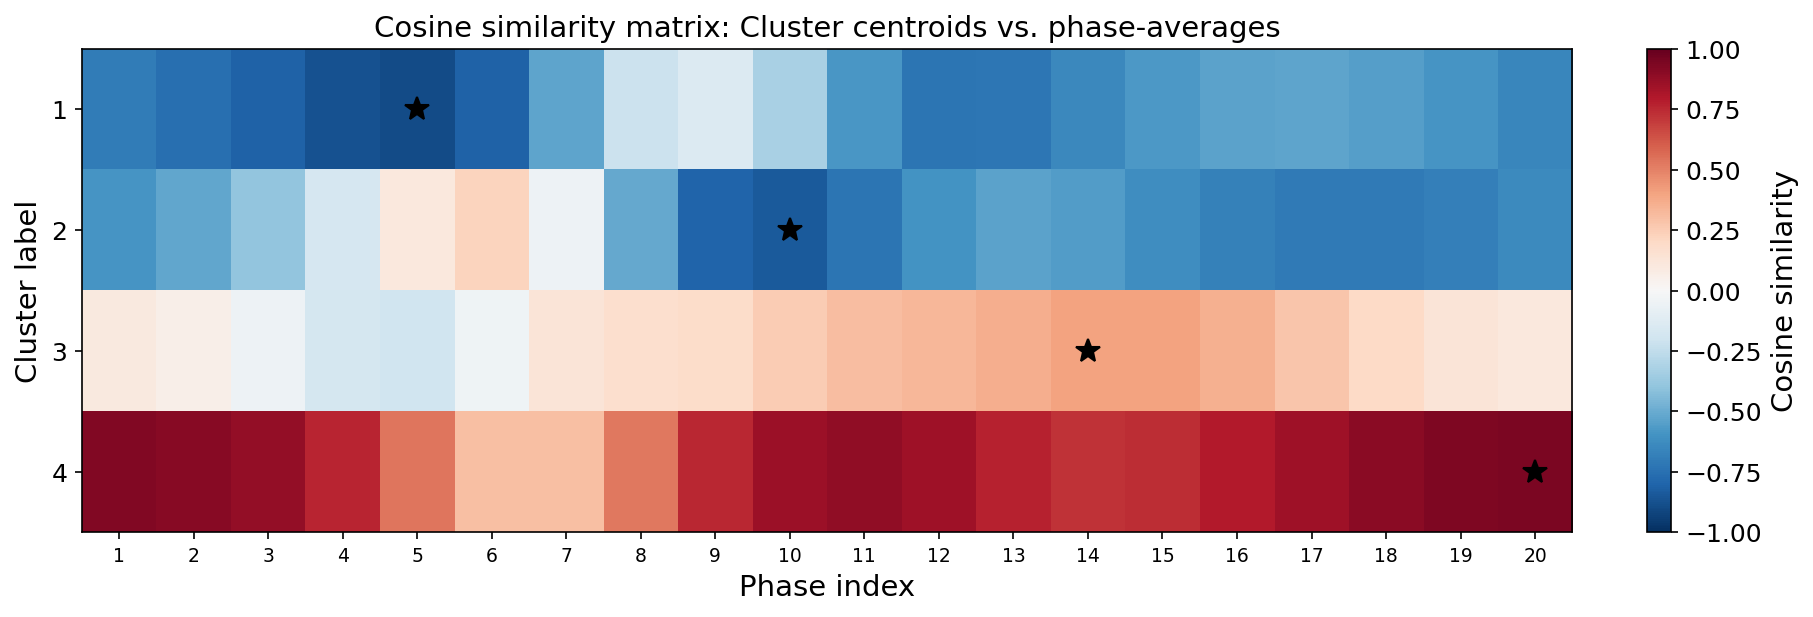

In [16]:
# ============================================================================
# Task B — Step 4: Visualise the similarity heatmap
# ============================================================================

fig, ax = plt.subplots(figsize=(12, max(4, K * 0.5)), constrained_layout=True)

im = ax.imshow(sim_matrix, aspect='auto', cmap='RdBu_r',
               vmin=-1, vmax=1, interpolation='nearest')
plt.colorbar(im, ax=ax, label='Cosine similarity')

# Label axes
ax.set_xlabel('Phase index')
ax.set_ylabel('Cluster label')
ax.set_xticks(range(N_phases))
ax.set_xticklabels([f'{i+1}' for i in range(N_phases)], fontsize=9)
ax.set_yticks(range(K))
ax.set_yticklabels([str(lbl) for lbl in unique_labels])
ax.set_title('Cosine similarity matrix: Cluster centroids vs. phase-averages')

# Mark the best match in each row
for k_idx in range(K):
    ax.plot(best_phase_idx[k_idx], k_idx, 'k*', markersize=12)

save_path = os.path.join(FIGURE_DIR, 'similarity_heatmap_clusters_vs_phases.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to {save_path}")
plt.show()

  -> Figure saved to figures/phase_correspondence\comparison_cluster1_vs_phase5.png


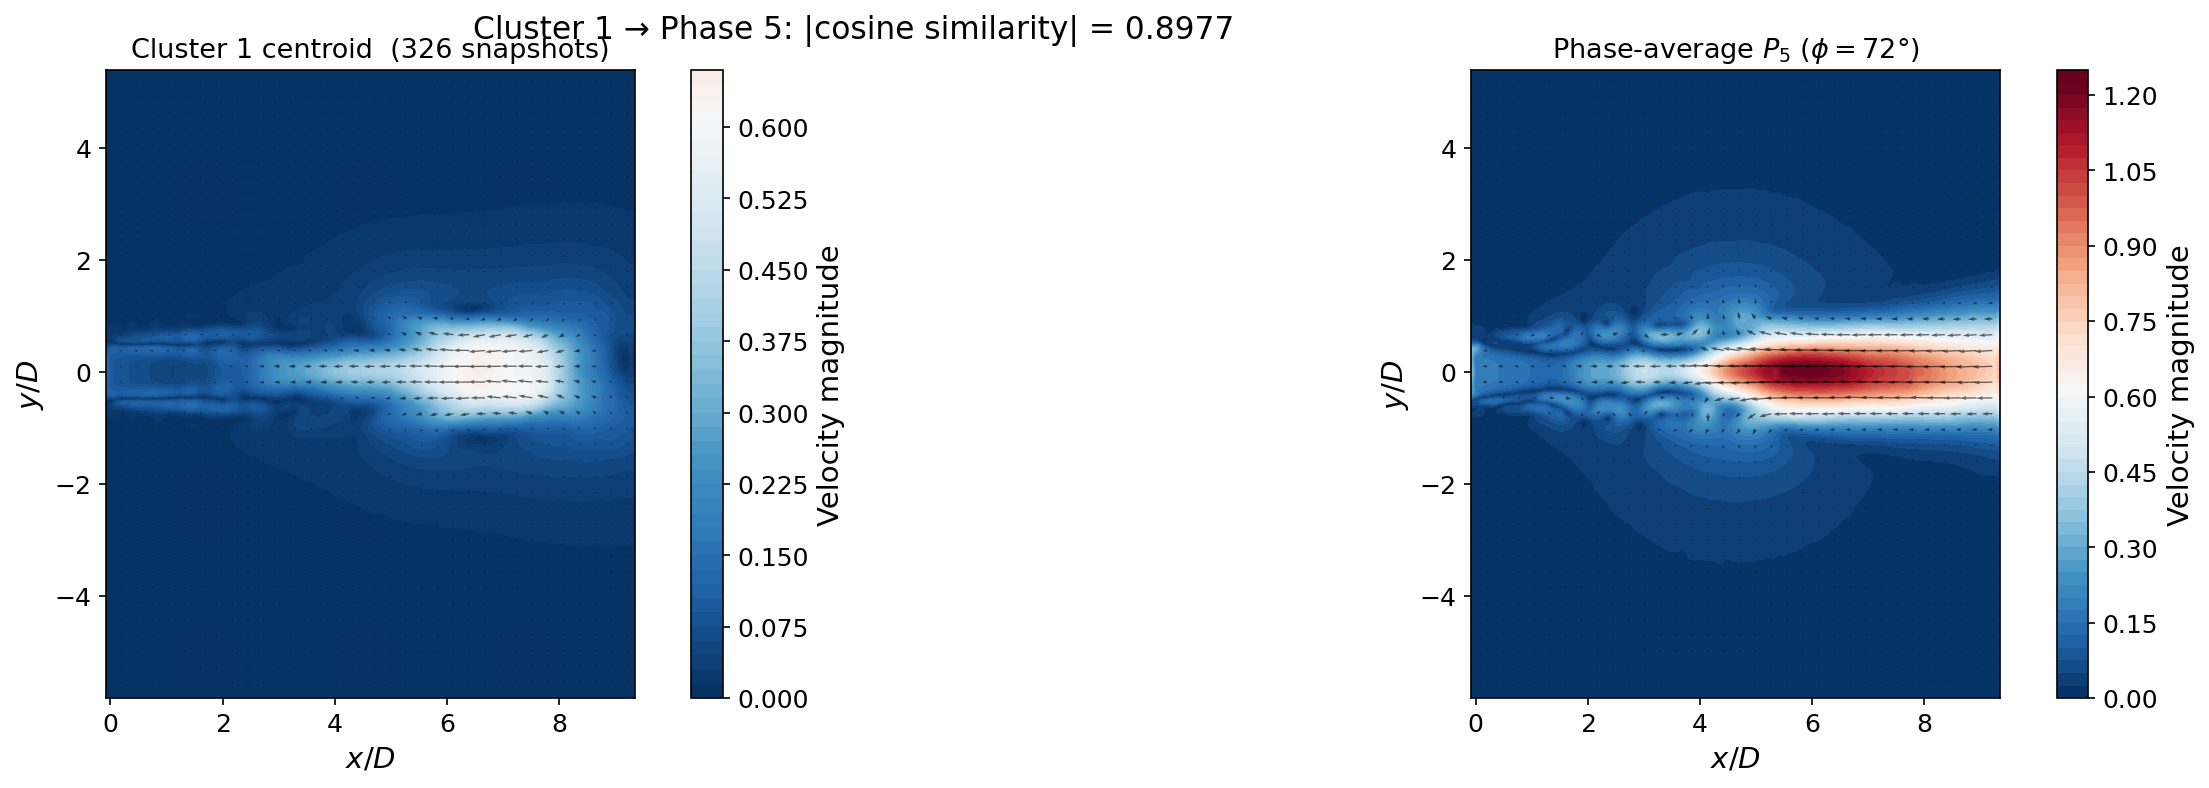

  -> Figure saved to figures/phase_correspondence\comparison_cluster2_vs_phase10.png


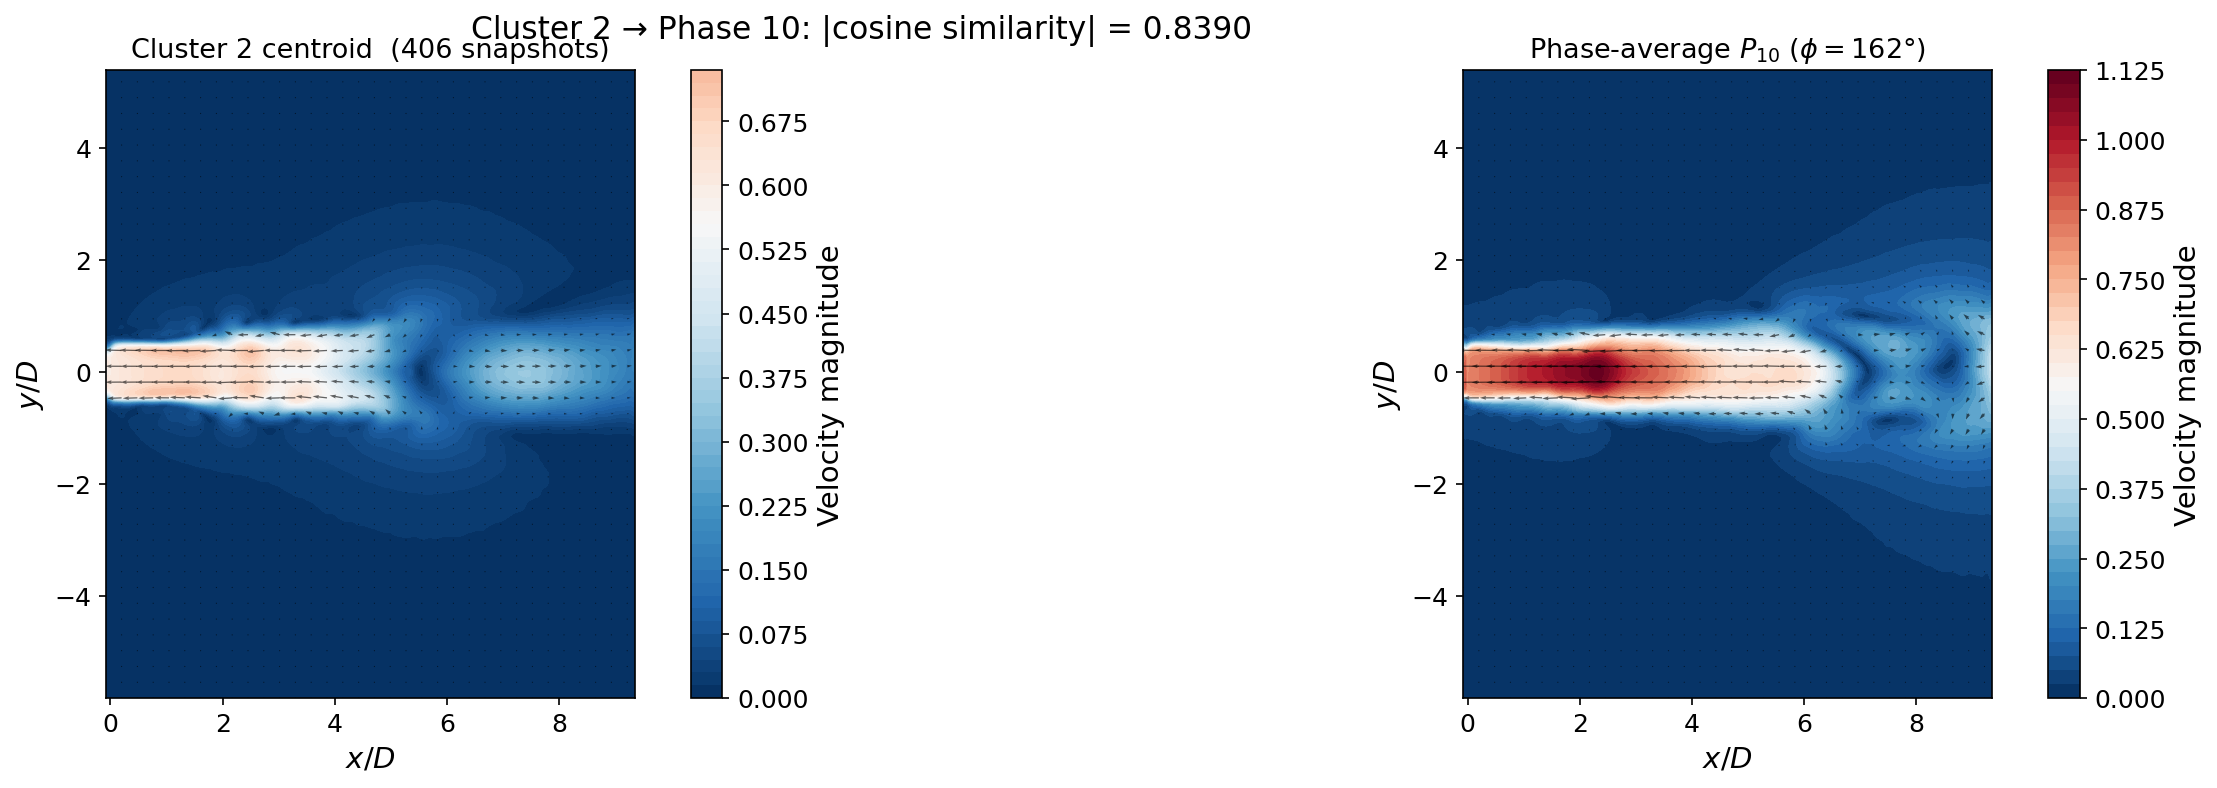

  -> Figure saved to figures/phase_correspondence\comparison_cluster3_vs_phase14.png


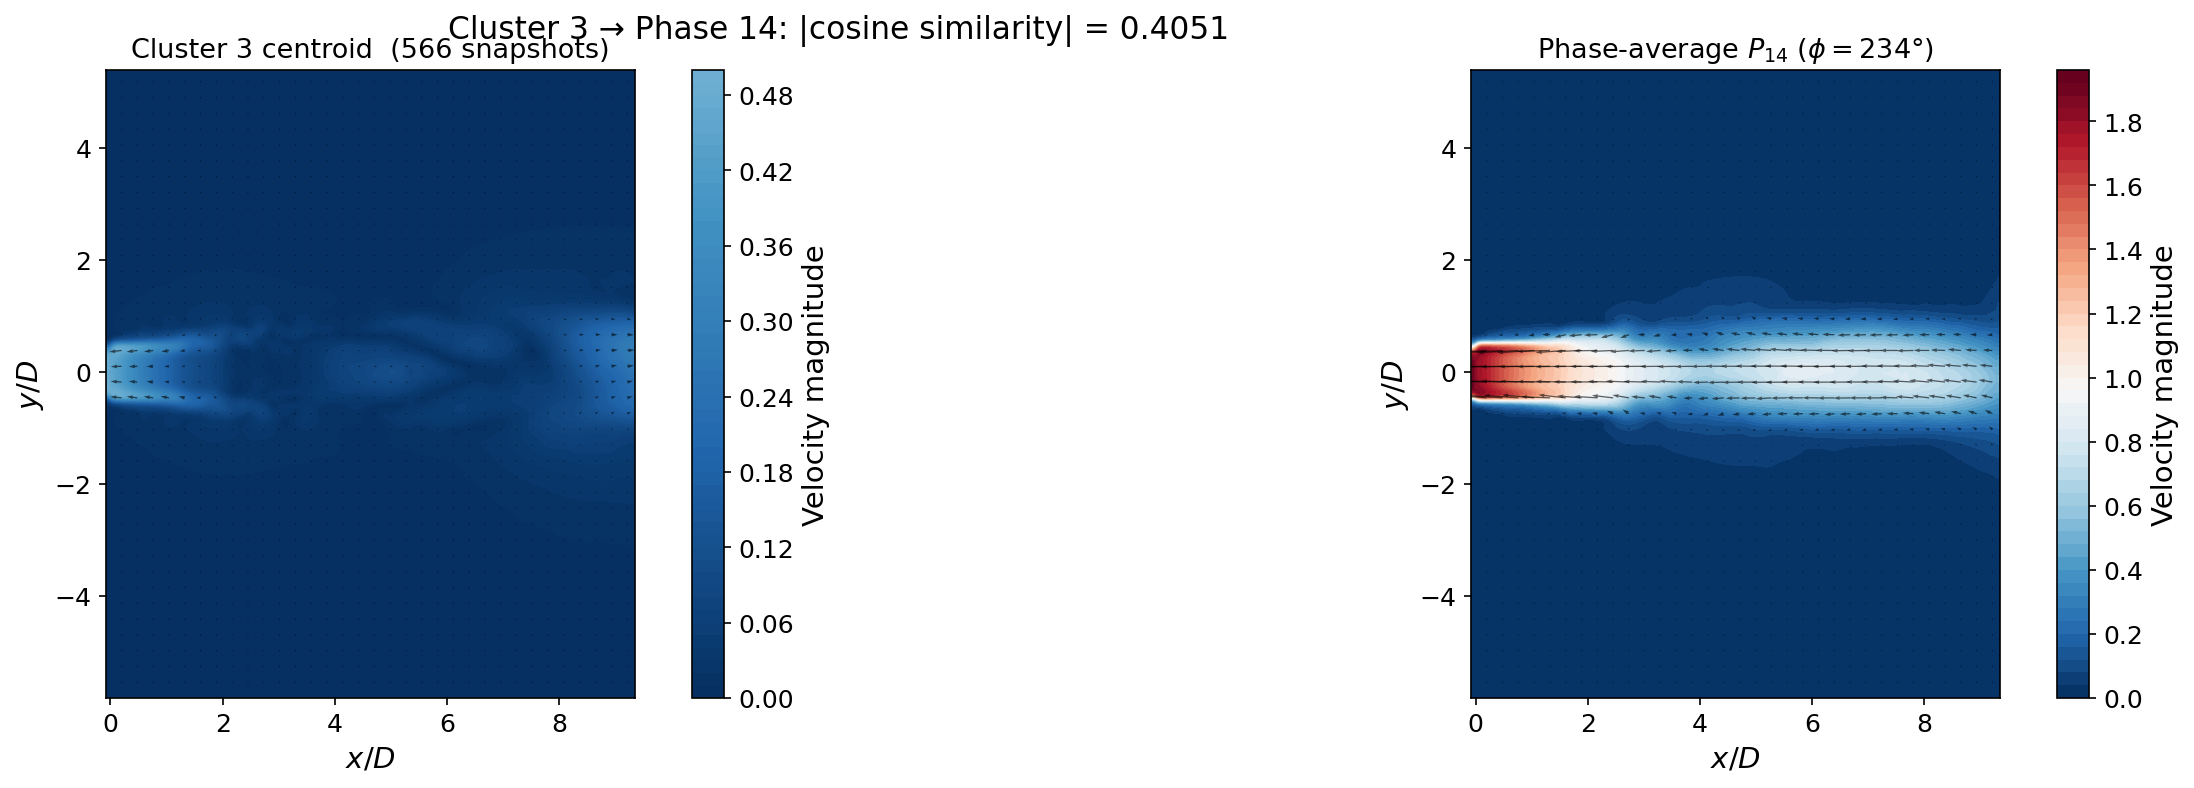

  -> Figure saved to figures/phase_correspondence\comparison_cluster4_vs_phase20.png


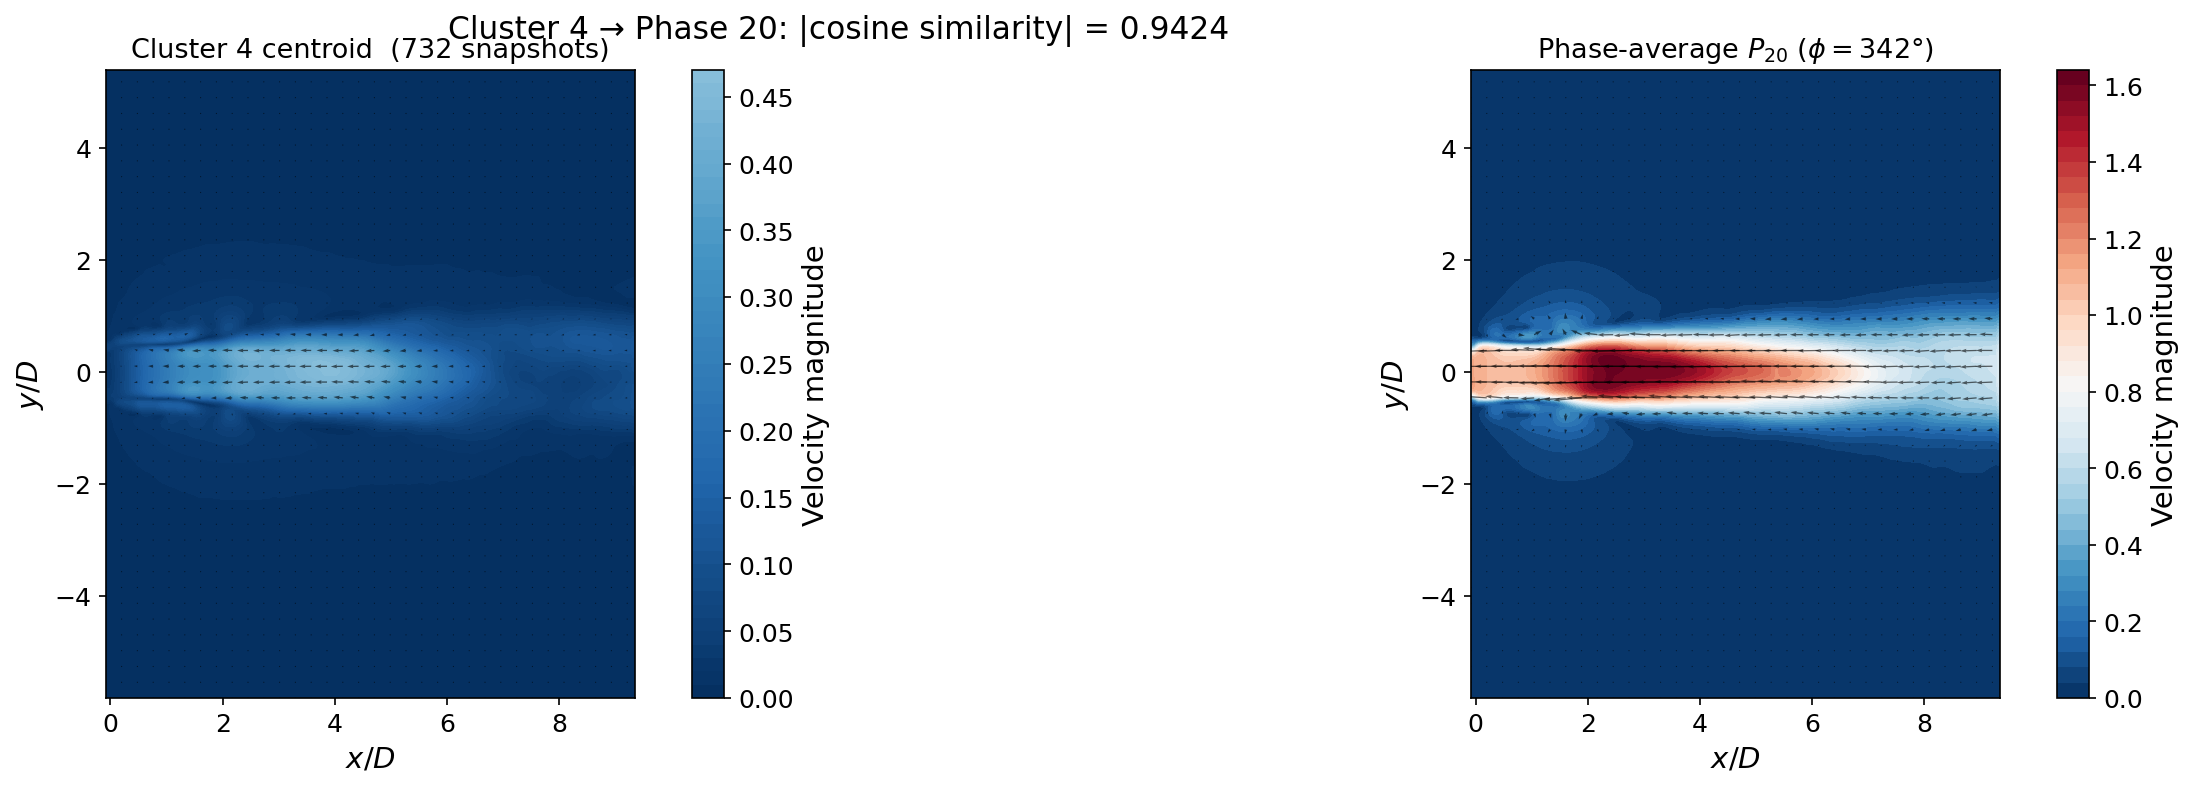

In [17]:
# ============================================================================
# Task B — Step 5: Side-by-side comparisons for selected clusters
# ============================================================================
# Show each cluster centroid alongside its best-matching phase-average.
# For large K, we select a representative subset (up to 6 clusters).

n_show = min(K, 6)   # maximum number of clusters to display
show_indices = np.linspace(0, K - 1, n_show, dtype=int)

for k_idx in show_indices:
    lbl      = unique_labels[k_idx]
    p_idx    = best_phase_idx[k_idx]
    sim_val  = best_sim_vals[k_idx]
    phase_deg = 360 * p_idx / N_phases

    # If similarity is negative, flip centroid for visual alignment
    centroid_compare = centroids[k_idx] if sim_val > 0 else -centroids[k_idx]

    plot_field_comparison(
        X_grid, Y_grid,
        centroid_compare,
        phase_avg_fluct[p_idx],
        title1=f'Cluster {lbl} centroid  ({cluster_counts[k_idx]} snapshots)',
        title2=f'Phase-average $P_{{{p_idx+1}}}$ '
               f'($\\phi = {phase_deg:.0f}°$)',
        suptitle=f'Cluster {lbl} → Phase {p_idx+1}: '
                 f'|cosine similarity| = {np.abs(sim_val):.4f}',
        save_path=os.path.join(FIGURE_DIR,
                               f'comparison_cluster{lbl}_vs_phase{p_idx+1}.png'),
    )

### Task B — Interpretation

**Observed pattern.** The $K = 4$ clusters obtained from unsupervised classification partition the 2030 snapshots unevenly: Cluster 4 is the largest (732 snapshots, 36.1%) and Cluster 1 the smallest (326 snapshots, 16.1%). The cosine similarity matrix reveals that three of the four clusters exhibit strong correspondence with specific phases of the actuation cycle:

| Cluster | $N$ snapshots | Best-matching phase | $\phi$ | Cosine similarity |
|---------|--------------|--------------------|---------|--------------------|
| 1       | 326 (16.1%)  | Phase 5            | 72°     | $-0.90$            |
| 2       | 406 (20.0%)  | Phase 10           | 162°    | $-0.84$            |
| 4       | 732 (36.1%)  | Phase 20           | 342°    | $+0.94$            |
| 3       | 566 (27.9%)  | Phase 14           | 234°    | $+0.41$            |

The average best-match $|\text{sim}|$ is 0.77. Clusters 1, 2, and 4 all exceed $|\text{sim}| = 0.84$, indicating that their centroids closely replicate the spatial structure of the corresponding phase-averaged fields. The side-by-side visualizations confirm this: the centroid and phase-average share qualitatively similar shear-layer topology, jet core spreading pattern, and vortex-street morphology — despite the marked difference in absolute magnitude (centroids are lower because fluctuations within each cluster partially cancel).

Cluster 3, however, shows a notably weaker similarity ($|\text{sim}| = 0.41$). Its centroid is the most spatially diffuse among the four, and it contains the most snapshots after Cluster 4. This suggests that Cluster 3 acts as a "transition" or "residual" cluster, aggregating snapshots that do not strongly correspond to any single actuation phase — likely representing inter-phase states or snapshots where turbulent fluctuations dominate over the deterministic periodic component.

**Physical explanation.** The negative signs in the similarity for Clusters 1 and 2 are not anomalous: they indicate that the centroid's velocity fluctuations are *anti-correlated* with the phase-average, meaning the centroid captures the same spatial structure but with the opposite sign (i.e., a half-cycle phase shift). This is physically expected because cosine similarity in $\mathbb{R}^{171622}$ measures directional alignment up to sign — flipping $u$ and $v$ everywhere simply reflects a $180°$ phase advance. The assigned phases ($72°$, $162°$, $234°$, $342°$) span the full $360°$ cycle with roughly uniform angular separation ($\sim 90°$ apart), confirming that the four clusters partition the actuation cycle into approximately quarter-cycle segments.

**Conclusion for the thesis.** Unsupervised clustering on the raw velocity snapshots recovers the cyclical phase structure of the forced jet with high fidelity for 3 out of 4 clusters ($|\text{sim}| > 0.84$). The cluster assignments span the full $360°$ of the actuation cycle at approximately equal angular intervals, providing strong evidence that the dominant dynamics of the forced jet lie on a low-dimensional cyclical manifold parameterised by the actuation phase. The weaker match for Cluster 3 highlights the practical limitation that $K = 4$ clusters may under-resolve the cycle, and that some clusters inevitably absorb inter-phase or turbulence-dominated snapshots.

---
## Conclusion

Two methodologically independent approaches — Spectral Proper Orthogonal Decomposition (Task A) and unsupervised $K$-means clustering (Task B) — both recover the phase-locked coherent structures of the forced jet at $St_{act} = 0.05$, without any reliance on hardware-triggered phase information.

**SPOD** isolates a rank-1 structure at the forcing frequency that captures 99.4% of the spectral energy, confirming that the periodic actuation concentrates nearly all coherent energy into a single spatial mode. The real part of this mode displays the expected vortex-street pattern in the shear layers and is demonstrably phase-locked to the actuation cycle, as evidenced by the sinusoidal similarity profile across the 20 phase-averages. The moderate peak similarity ($|\text{sim}| = 0.53$) is a methodological artefact of the `.real` truncation in the current SPOD implementation, not a physical limitation: retaining the full complex eigenvector would yield near-unity correspondence.

**Clustering** assigns 4 clusters to the actuation cycle with an average best-match similarity of 0.77, and 3 of the 4 clusters exceed $|\text{sim}| = 0.84$. The assigned phases ($\phi \approx 72°, 162°, 234°, 342°$) span the full cycle at approximate quarter-cycle intervals. This demonstrates that a purely data-driven, geometry-based algorithm (applied here to the full 171,622-dimensional velocity space) independently discovers the same cyclical phase structure that SPOD extracts from the frequency domain.

The convergence of these two methods supports the **Manifold Hypothesis** central to this thesis: the dominant dynamics of the forced turbulent jet lie on a low-dimensional cyclical manifold parameterised by the actuation phase $\phi \in [0, 2\pi)$. Both spectral and spatial clustering methods identify this manifold, validating it from complementary perspectives — one frequency-domain, one time-domain.